# Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import shap
import lime.lime_tabular
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
# Load Dataset
df = pd.read_csv("Cloud_Anomaly_Dataset.csv")

# Display first five rows
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,Anomaly status
0,c5215826-6237-4a33-9312-72c1df909881,25-01-2023 09:10,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting,0
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,26-01-2023 04:46,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed,0
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,13-01-2023 23:39,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed,0
3,ea8455b0-251c-4470-b7ea-8d40476e3434,14-01-2023 19:59,79.172504,2.972252,926.374030,173.559325,8644.0,55.702673,0.779499,compute,medium,completed,0
4,fd28310b-be6f-4320-a664-de02274993d9,18-01-2023 11:22,87.001215,46.620176,437.188115,77.054702,9427.0,NaN,0.207164,NaN,low,waiting,0


In [ ]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277570 entries, 0 to 277569
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   vm_id                      249595 non-null  object 
 1   timestamp                  277570 non-null  object 
 2   cpu_usage                  250130 non-null  float64
 3   memory_usage               249775 non-null  float64
 4   network_traffic            249725 non-null  float64
 5   power_consumption          250018 non-null  float64
 6   num_executed_instructions  249637 non-null  float64
 7   execution_time             249960 non-null  float64
 8   energy_efficiency          249616 non-null  float64
 9   task_type                  249580 non-null  object 
 10  task_priority              249674 non-null  object 
 11  task_status                249621 non-null  object 
 12  Anomaly status             277570 non-null  int64  
dtypes: float64(7), int64(1), obje

In [ ]:
# Descriptive Statistics
df.describe()

,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,Anomaly status
count,250130.000000,249775.000000,249725.000000,250018.000000,249637.000000,249960.000000,249616.000000,277570.000000
mean,50.013258,49.967249,500.554083,249.987238,5002.490284,50.011964,0.500369,0.059999
std,28.895806,28.879090,288.787794,144.662676,2882.806422,28.837634,0.288547,0.237486
min,0.000071,0.000016,0.002542,0.000802,0.000000,0.000172,0.000004,0.000000
25%,24.880023,24.965105,250.298114,124.199907,2506.000000,25.098016,0.250375,0.000000
50%,50.023806,49.912051,500.736963,250.397212,5000.000000,50.005593,0.500834,0.000000
75%,75.097896,74.960052,750.720026,375.485305,7499.000000,75.043715,0.750112,0.000000
max,99.999171,99.999907,999.998686,499.998819,9999.000000,99.998831,0.999994,1.000000


# EDA

/tmp/ipykernel_46866/3877227388.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


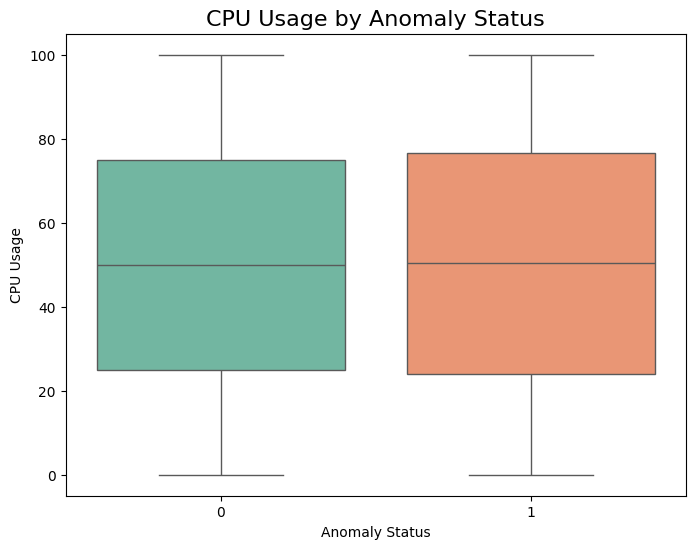

In [ ]:
# CPU Usage by Anomaly Status
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Anomaly status',
    y='cpu_usage',
    data=df,
    palette='Set2'
)

plt.title("CPU Usage by Anomaly Status", fontsize=16)
plt.xlabel("Anomaly Status")
plt.ylabel("CPU Usage")

plt.show()

/tmp/ipykernel_46866/1374879635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


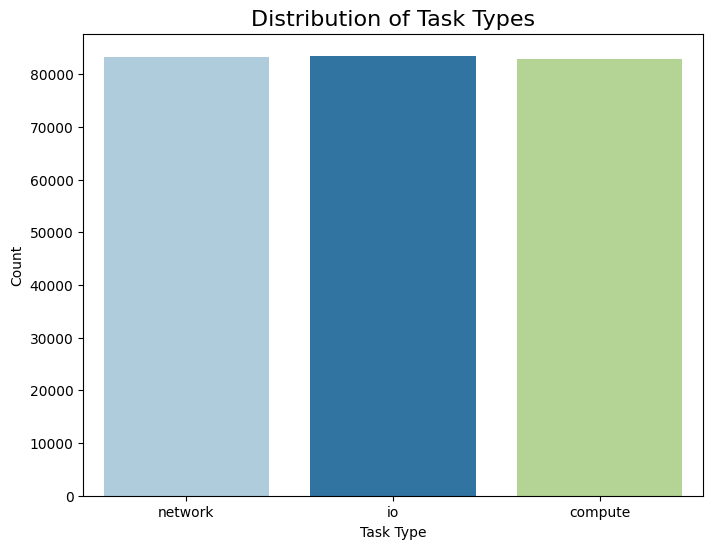

In [ ]:
# Count Plot of Task Types
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='task_type',
    palette='Paired'
)

plt.title("Distribution of Task Types", fontsize=16)
plt.xlabel("Task Type")
plt.ylabel("Count")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


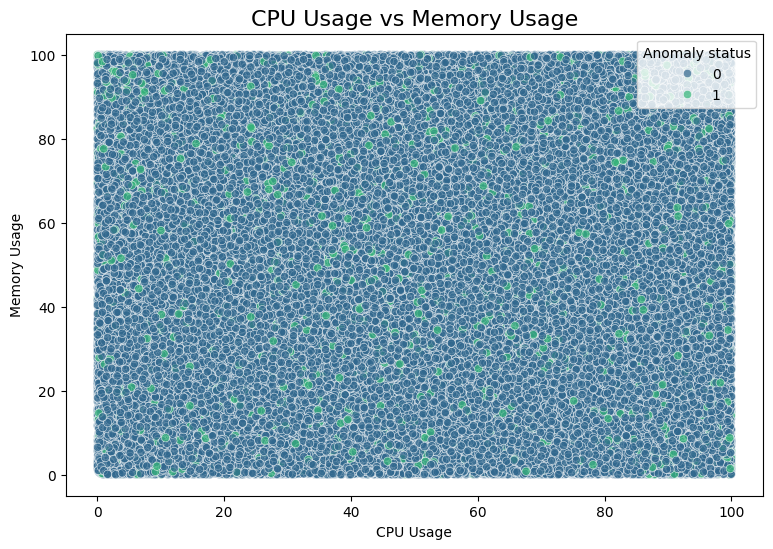

In [ ]:
# CPU Usage vs Memory Usage
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='cpu_usage',
    y='memory_usage',
    hue='Anomaly status',
    palette='viridis',
    alpha=0.7
)

plt.title("CPU Usage vs Memory Usage", fontsize=16)
plt.xlabel("CPU Usage")
plt.ylabel("Memory Usage")

plt.show()

/tmp/ipykernel_46866/2986840256.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


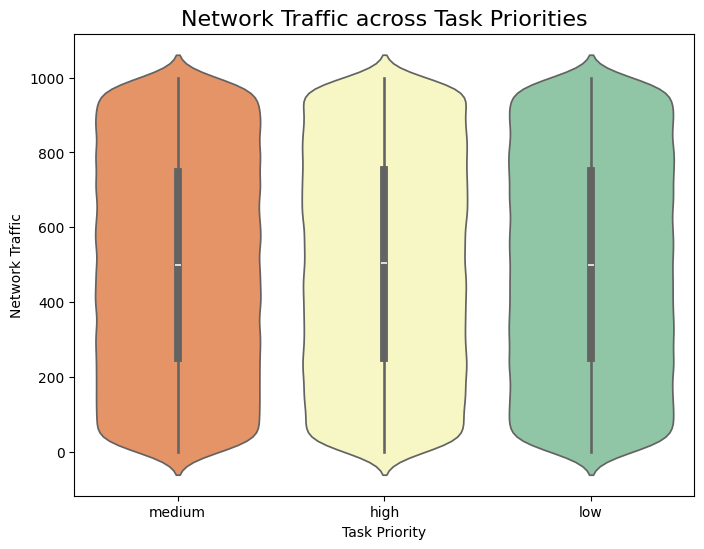

In [ ]:
# Network Traffic by Task Priority
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x='task_priority',
    y='network_traffic',
    palette='Spectral'
)

plt.title("Network Traffic across Task Priorities", fontsize=16)
plt.xlabel("Task Priority")
plt.ylabel("Network Traffic")

plt.show()

# Data Preprocessing

In [ ]:
# Check missing values
print(df.isnull().sum())

vm_id                        27975
timestamp                        0
cpu_usage                    27440
memory_usage                 27795
network_traffic              27845
power_consumption            27552
num_executed_instructions    27933
execution_time               27610
energy_efficiency            27954
task_type                    27990
task_priority                27896
task_status                  27949
Anomaly status                   0
dtype: int64


In [ ]:
# Remove rows with missing values
df = df.dropna()

In [ ]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Feature Engineering
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

# Create new features
df['Day'] = df['timestamp'].dt.day
df['Month'] = df['timestamp'].dt.month
df['Hour'] = df['timestamp'].dt.hour

# Drop original timestamp column
df.drop('timestamp', axis=1, inplace=True)

In [ ]:
# Remove VM ID
df.drop('vm_id', axis=1, inplace=True)

In [ ]:
# Feature Encoding
# Initialize encoder
encoder = LabelEncoder()

# Encode categorical columns
categorical_columns = [
    'task_type',
    'task_priority',
    'task_status'
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [ ]:
# Feature Scaling
# Features to scale
numerical_features = [
    'cpu_usage',
    'memory_usage',
    'network_traffic',
    'power_consumption',
    'num_executed_instructions',
    'execution_time',
    'energy_efficiency',
    'Day',
    'Month',
    'Hour'
]

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Machine Learning

In [ ]:
# Features and Target
X = df.drop('Anomaly status', axis=1)
y = df['Anomaly status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (69413, 13)
Testing Samples  : (17354, 13)


In [ ]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

## Decision Tree Model

Decision Tree Accuracy : 86.38%

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.90      0.93     16345
           1       0.15      0.28      0.19      1009

    accuracy                           0.86     17354
   macro avg       0.55      0.59      0.56     17354
weighted avg       0.91      0.86      0.88     17354

ROC-AUC Score : 0.5916


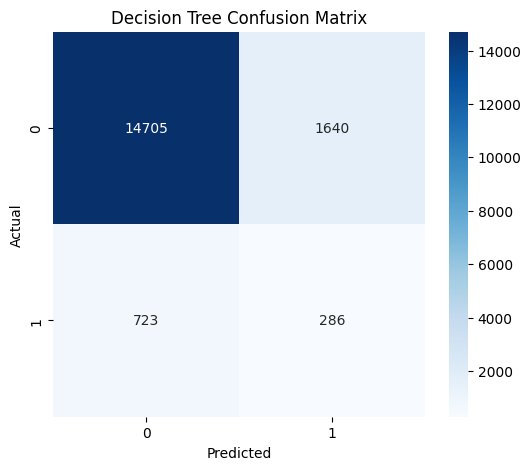

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred_dt) * 100
print(f"Decision Tree Accuracy : {accuracy:.2f}%")

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

# ROC AUC
auc = roc_auc_score(y_test, y_prob_dt)
print(f"ROC-AUC Score : {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest Model

Random Forest Accuracy : 85.16%

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     16345
           1       0.16      0.36      0.22      1009

    accuracy                           0.85     17354
   macro avg       0.56      0.62      0.57     17354
weighted avg       0.91      0.85      0.88     17354

ROC-AUC Score : 0.8370


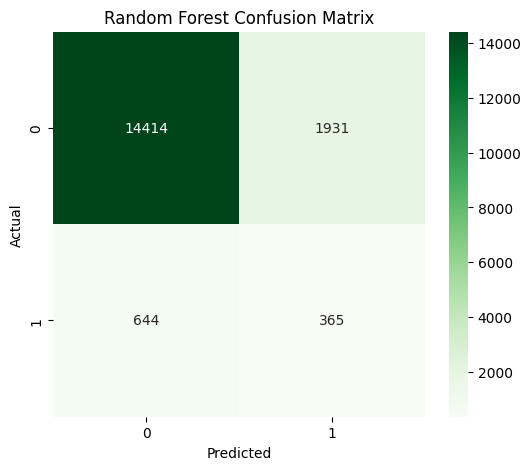

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred_rf) * 100
print(f"Random Forest Accuracy : {accuracy:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

auc = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC Score : {auc:.4f}")

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Gradient Boosting Model

Gradient Boosting Accuracy : 76.04%

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     16345
           1       0.16      0.74      0.27      1009

    accuracy                           0.76     17354
   macro avg       0.57      0.75      0.56     17354
weighted avg       0.93      0.76      0.82     17354

ROC-AUC Score : 0.8362


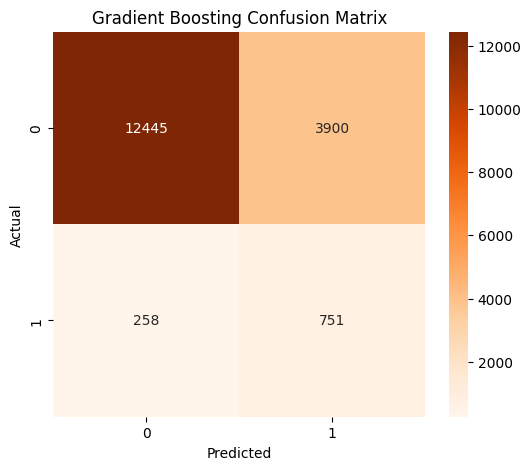

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_resampled, y_train_resampled)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred_gb) * 100
print(f"Gradient Boosting Accuracy : {accuracy:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred_gb))

auc = roc_auc_score(y_test, y_prob_gb)
print(f"ROC-AUC Score : {auc:.4f}")

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
           fmt='d',
            cmap='Oranges')

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost Model

XGBoost Accuracy : 93.82%

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     16345
           1       0.22      0.02      0.04      1009

    accuracy                           0.94     17354
   macro avg       0.58      0.51      0.51     17354
weighted avg       0.90      0.94      0.91     17354

ROC-AUC Score : 0.8403


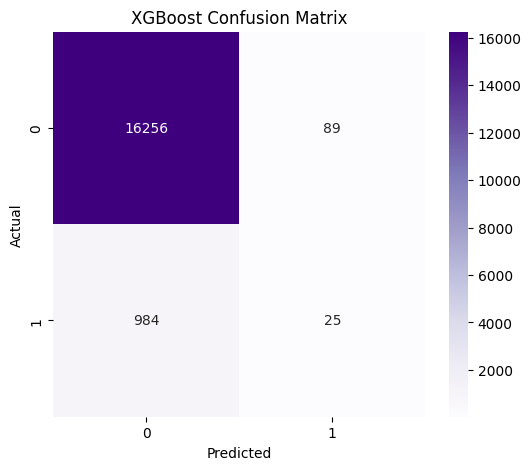

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred_xgb) * 100
print(f"XGBoost Accuracy : {accuracy:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

auc = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC-AUC Score : {auc:.4f}")

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples')

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Store results
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy (%)": [
        accuracy_score(y_test, pred) * 100
        for pred in [y_pred_dt, y_pred_rf, y_pred_gb, y_pred_xgb]
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, prob)
        for prob in [y_prob_dt, y_prob_rf, y_prob_gb, y_prob_xgb]
    ]
})

print(results.sort_values("Accuracy (%)", ascending=False))

               Model  Accuracy (%)   ROC-AUC
3            XGBoost     93.816987  0.840315
0      Decision Tree     86.383543  0.591556
1      Random Forest     85.161922  0.837001
2  Gradient Boosting     76.040106  0.836205


/tmp/ipykernel_46866/698413966.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


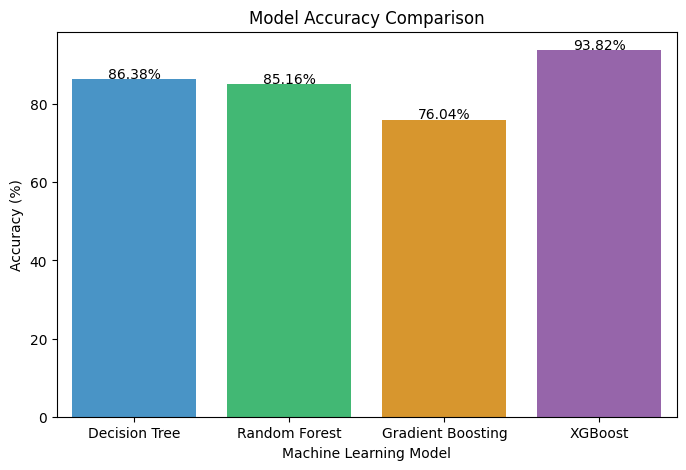

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)",
    palette=["#3498db",
             "#2ecc71",
             "#f39c12",
             "#9b59b6"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(results["Accuracy (%)"]):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.show()

# Explainable AI

## SHAP

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

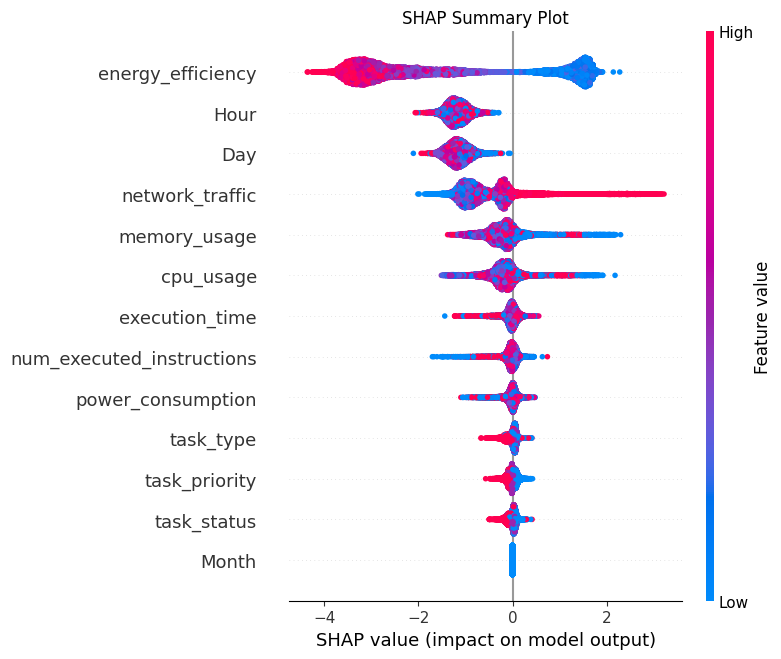

In [ ]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

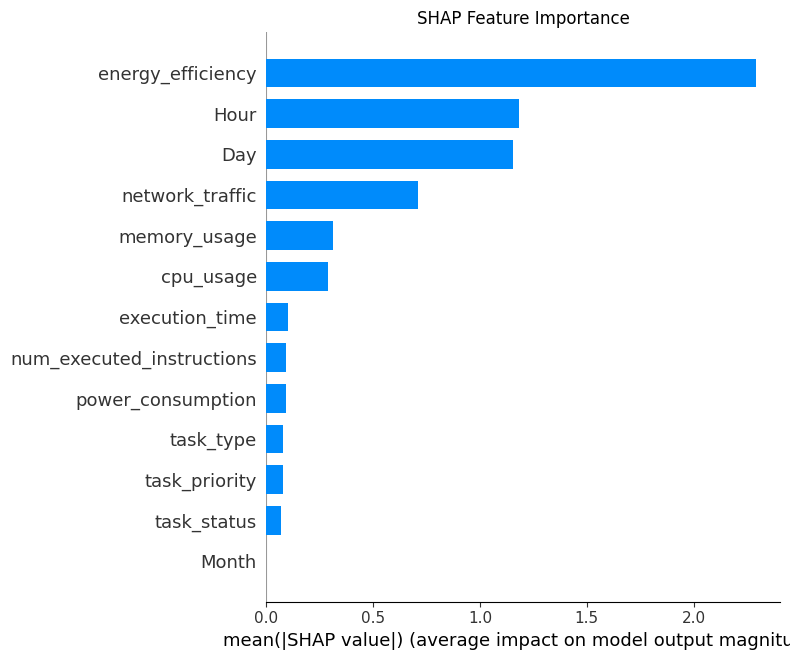

In [ ]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

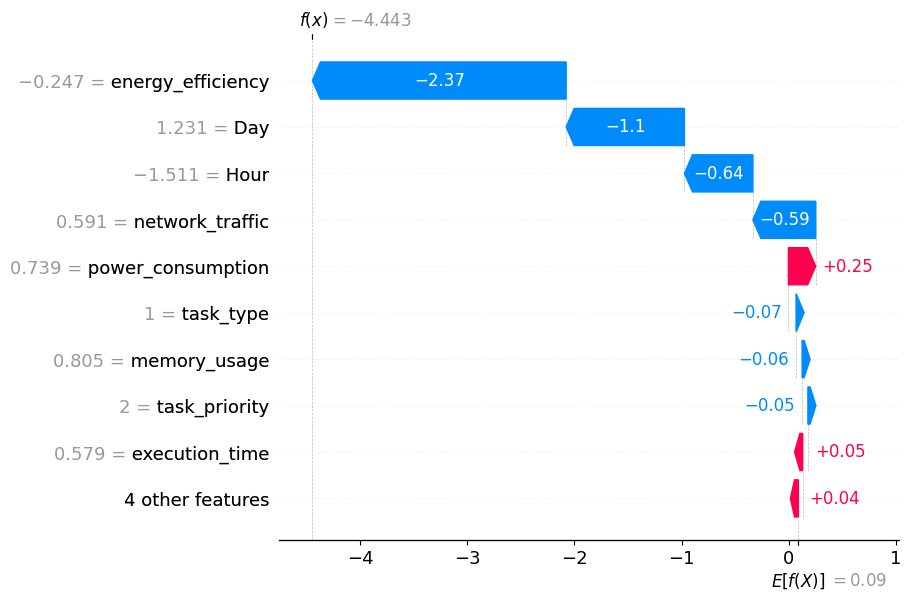

In [ ]:
# Explain the first test instance
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

## LIME

In [ ]:
# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_resampled.values,
    feature_names=X_train_resampled.columns,
    class_names=["Normal", "Anomaly"],
    mode="classification"
)

In [ ]:
# Select one instance
instance = X_test.iloc[0]

# Generate explanation
lime_exp = lime_explainer.explain_instance(
    instance.values,
    xgb.predict_proba,
    num_features=10
)

In [ ]:
lime_exp.show_in_notebook(show_table=True)

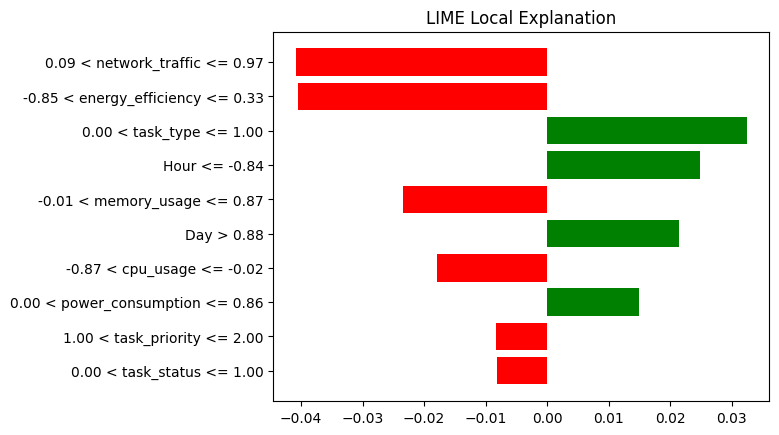

In [ ]:
fig = lime_exp.as_pyplot_figure()
plt.title("LIME Local Explanation")
plt.show()

In [ ]:
print("LIME Feature Contributions\n")

for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

LIME Feature Contributions

0.09 < network_traffic <= 0.97: -0.0408
-0.85 < energy_efficiency <= 0.33: -0.0406
0.00 < task_type <= 1.00: 0.0324
Hour <= -0.84: 0.0248
-0.01 < memory_usage <= 0.87: -0.0234
Day > 0.88: 0.0214
-0.87 < cpu_usage <= -0.02: -0.0179
0.00 < power_consumption <= 0.86: 0.0149
1.00 < task_priority <= 2.00: -0.0084
0.00 < task_status <= 1.00: -0.0082


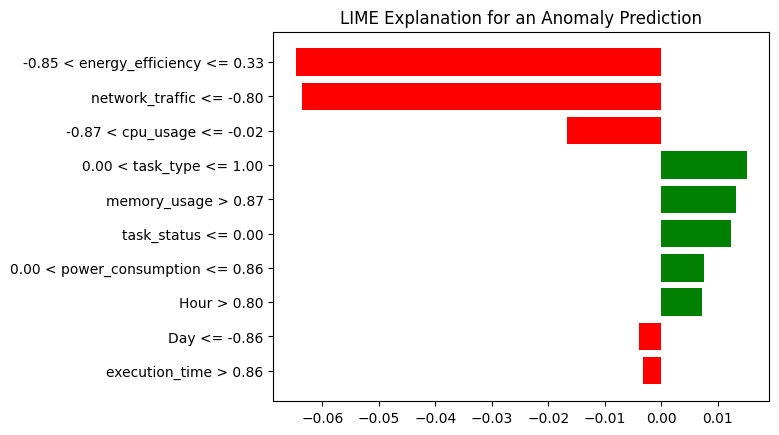

In [ ]:
# Find the first anomaly in the test set
anomaly_index = y_test[y_test == 1].index[0]

lime_exp = lime_explainer.explain_instance(
    X_test.loc[anomaly_index].values,
    xgb.predict_proba,
    num_features=10
)

lime_exp.as_pyplot_figure()
plt.title("LIME Explanation for an Anomaly Prediction")
plt.show()